Purpose: Look into results of GO enrichment on ASE & HybridExpress gene sets.<br>
Author: Anna Pardo<br>
Date initiated: May 5, 2026

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load results
aseres = pd.read_csv("./ASE_GOenrich_res.txt",sep="\t",header="infer")
aseres.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,1.195987e-07,GO:0006412,2.811764e-04,C3+CAM_W_Yf,BP,translation,1053.0,149.0,97.99,1.2e-07,translation
1,6.444957e-14,GO:0006468,4.545628e-10,C3+CAM_W_Yf,BP,protein phosphorylation,1876.0,270.0,174.58,6.4e-14,protein phosphorylation
2,8.766189e-07,GO:0016310,1.545698e-03,C3+CAM_W_Yf,BP,phosphorylation,2215.0,271.0,206.13,8.8e-07,phosphorylation
3,9.095252e-09,GO:0019538,3.207441e-05,C3+CAM_W_Yf,BP,protein metabolic process,5985.0,668.0,556.96,9.1e-09,protein metabolic process
4,1.754842e-08,GO:0006412,3.454909e-05,facultative CAM_W_Yf,BP,translation,1053.0,144.0,90.99,1.8e-08,translation


In [5]:
with open("./ASE_GO_forRevigo.txt","w+") as outfile:
    for i in aseres["GO.term"].unique():
        outfile.write(i+"\n")

In [6]:
heres = pd.read_csv("./expression_partitioning_downstream/HybExp_GOenrich_res.txt",sep="\t",header="infer")
heres.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,1.818434e-06,GO:0009060,0.004233,C3+CAM_D_ADD,BP,aerobic respiration,88,51,29.36,1.8e-06,aerobic respiration
1,2.652171e-07,GO:0010112,0.001852,C3+CAM_D_ADD,BP,regulation of systemic acquired resistan...,32,25,10.68,2.7e-07,regulation of systemic acquired resistance
2,6.969018e-07,GO:0015980,0.002433,C3+CAM_D_ADD,BP,energy derivation by oxidation of organi...,138,74,46.04,7.0e-07,energy derivation by oxidation of organic comp...
3,1.463696e-05,GO:0045333,0.025552,C3+CAM_D_ADD,BP,cellular respiration,109,58,36.37,1.5e-05,cellular respiration
4,1.423154e-06,GO:0000027,0.000491,C3+CAM_D_DOWN,BP,ribosomal large subunit assembly,52,34,17.04,1.4e-06,ribosomal large subunit assembly


In [7]:
with open("./HybExp_GO_forRevigo.txt","w+") as outfile:
    for i in heres["GO.term"].unique():
        outfile.write(i+"\n")

In [8]:
# load Revigo results
revhe = pd.read_csv("./Revigo_BP_OnScreenTable_HybExp_GO.csv",sep=",",header="infer",usecols=["TermID","Name"])
revase = pd.read_csv("./Revigo_BP_OnScreenTable_ASE_GO.csv",sep=",",header="infer",usecols=["TermID","Name"])

In [9]:
revase.head()

,TermID,Name
0,GO:0000038,very long-chain fatty acid metabolic process
1,GO:0000041,transition metal ion transport
2,GO:0000122,negative regulation of transcription by RNA po...
3,GO:0000165,MAPK cascade
4,GO:0000226,microtubule cytoskeleton organization


In [10]:
# make ASE figure(s) first
subase = aseres[["GO.term","p.adj","regset","Annotated","Significant","Expected","Descr"]].merge(revase.rename(columns={
    "TermID":"GO.term"
}))
subase.head()

,GO.term,p.adj,regset,Annotated,Significant,Expected,Descr,Name
0,GO:0006412,0.000281,C3+CAM_W_Yf,1053.0,149.0,97.99,translation,translation
1,GO:0006412,0.000035,facultative CAM_W_Yf,1053.0,144.0,90.99,translation,translation
2,GO:0006412,0.000117,C3+CAM_D_Yf,1053.0,150.0,97.44,translation,translation
3,GO:0006412,0.000018,CAM_W_Yf,1053.0,147.0,92.24,translation,translation
4,GO:0006412,0.000040,CAM_D_Yf,1053.0,142.0,89.33,translation,translation


In [11]:
plotase = subase.pivot(index="Descr",columns="regset",values="p.adj")

In [13]:
len(plotase.index)

504

In [14]:
subase.groupby("regset").count().reset_index()[["regset","GO.term"]]

,regset,GO.term
0,C3+CAM_D_Ya,336
1,C3+CAM_D_Yf,5
2,C3+CAM_W_Ya,336
3,C3+CAM_W_Yf,3
4,CAM_D_Ya,352
5,CAM_D_Yf,3
6,CAM_W_Ya,338
7,CAM_W_Yf,3
8,facultative CAM_D_Ya,257
9,facultative CAM_D_Yf,2


In [15]:
aseres.groupby("regset").count().reset_index()[["regset","GO.term"]]

,regset,GO.term
0,C3+CAM_D_Ya,657
1,C3+CAM_D_Yf,6
2,C3+CAM_W_Ya,650
3,C3+CAM_W_Yf,4
4,CAM_D_Ya,655
5,CAM_D_Yf,4
6,CAM_W_Ya,654
7,CAM_W_Yf,4
8,facultative CAM_D_Ya,502
9,facultative CAM_D_Yf,3


In [22]:
# plot just Yf gene sets (all terms, since there aren't many...)
yfcols = [c for c in plotase.columns if "Yf" in c]
plotyf = plotase[yfcols].dropna(how="all")

In [23]:
len(plotyf.index)

6

In [24]:
plotyf

regset,C3+CAM_D_Yf,C3+CAM_W_Yf,CAM_D_Yf,CAM_W_Yf,facultative CAM_D_Yf,facultative CAM_W_Yf
Descr,,,,,,
obsolete glycine biosynthetic process from L-serine,0.020897,NaN,NaN,NaN,NaN,NaN
phosphorus metabolic process,NaN,NaN,NaN,NaN,NaN,8.518082e-03
phosphorylation,0.000962,0.001546,0.007226,0.001693,NaN,3.454909e-05
protein metabolic process,0.000009,0.000032,0.000002,0.000008,0.006655,3.381242e-07
tetrahydrofolate interconversion,0.048124,NaN,NaN,NaN,NaN,NaN
translation,0.000117,0.000281,0.000040,0.000018,0.000002,3.454909e-05


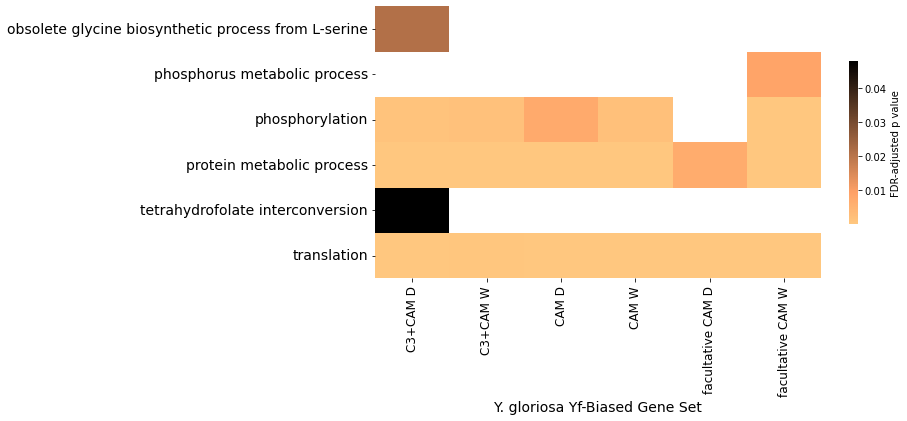

In [29]:
plt.subplots(figsize=(10,5))
sns.heatmap(plotyf,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,6.5,1),labels = ["C3+CAM D","C3+CAM W","CAM D","CAM W","facultative CAM D",
                                               "facultative CAM W"],fontsize=12)
plt.xlabel("Y. gloriosa Yf-Biased Gene Set",fontsize=14)

plt.savefig("./ASEYf_GO_heatmap_Revigo.png",dpi=300,bbox_inches="tight")
plt.savefig("./ASEYf_GO_heatmap_Revigo.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./ASEYf_GO_heatmap_Revigo.svg",dpi=300,bbox_inches="tight")

In [30]:
plotya = plotase.drop(yfcols,axis=1).dropna(how="all")
plotya.head()

regset,C3+CAM_D_Ya,C3+CAM_W_Ya,CAM_D_Ya,CAM_W_Ya,facultative CAM_D_Ya,facultative CAM_W_Ya
Descr,,,,,,
'de novo' protein folding,0.006597,0.001318,0.013507,0.018800,0.035363,0.035195
DNA biosynthetic process,0.044106,0.026146,0.002770,0.026225,0.018579,0.042290
DNA conformation change,0.000216,0.000205,0.000420,0.000035,0.003573,0.000269
DNA dealkylation,NaN,0.029308,0.040363,0.047661,0.011496,0.046884
DNA geometric change,0.045377,0.025028,0.043330,0.009551,NaN,0.018351


In [31]:
len(plotya.index)

499

In [32]:
# split by treatment for Ya plotting
plotd = plotya[[c for c in plotya.columns if "D" in c]].dropna(how="all")
len(plotd.index)

436

In [33]:
len(plotd.dropna(how="any").index)

202

In [34]:
plotw = plotya[[c for c in plotya.columns if "W" in c]].dropna(how="all")
len(plotw.index)

445

In [35]:
len(plotw.dropna(how="any").index)

263

In [39]:
plotd.dropna(how="any",inplace=True)
plotd_reduced = plotd[(plotd["C3+CAM_D_Ya"]<0.005) & (plotd["CAM_D_Ya"]<0.005) & (plotd["facultative CAM_D_Ya"]<0.005)]
len(plotd_reduced.index)

113

In [40]:
plotw.dropna(how="any",inplace=True)
plotw_reduced = plotw[(plotw["C3+CAM_W_Ya"]<0.005) & (plotw["CAM_W_Ya"]<0.005) & (plotw["facultative CAM_W_Ya"]<0.005)]
len(plotw_reduced.index)

144

In [41]:
plotd_reduced.head()

regset,C3+CAM_D_Ya,CAM_D_Ya,facultative CAM_D_Ya
Descr,,,
DNA conformation change,2.160453e-04,4.203242e-04,3.573109e-03
DNA metabolic process,5.188923e-04,3.137926e-04,2.980198e-03
RNA 3'-end processing,1.955735e-03,7.538069e-04,4.767649e-03
RNA modification,4.794514e-17,2.523757e-11,1.015586e-06
RNA processing,2.510818e-10,2.338959e-11,4.599800e-08


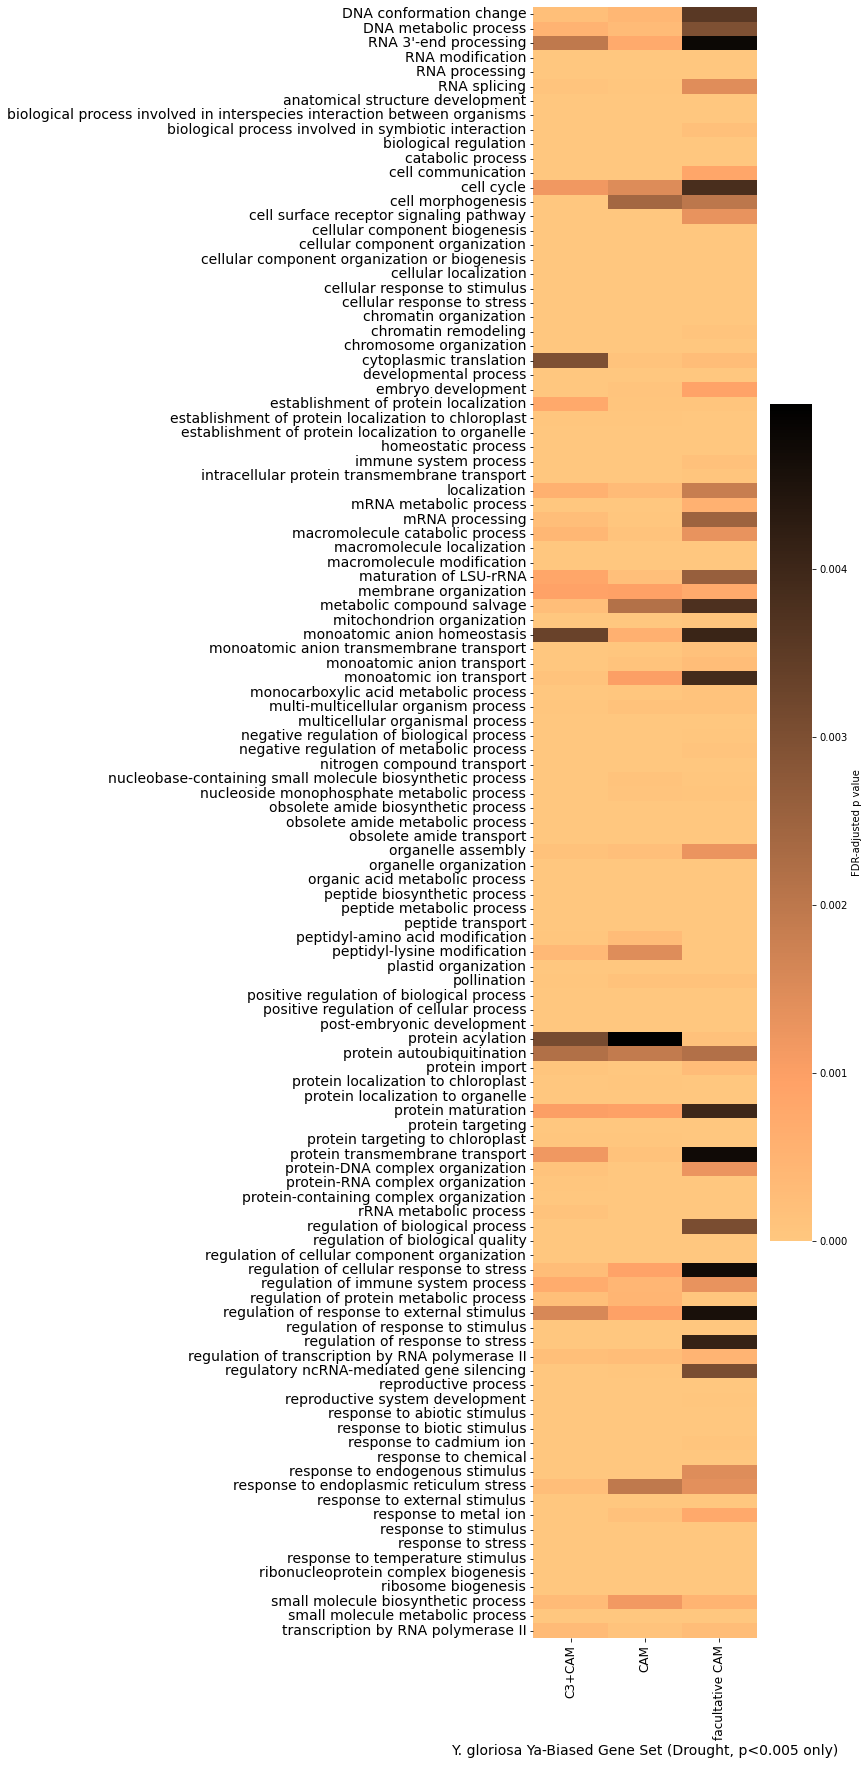

In [44]:
plt.subplots(figsize=(5,30))
sns.heatmap(plotd_reduced,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,3.5,1),labels = ["C3+CAM","CAM","facultative CAM"],fontsize=12)
plt.xlabel("Y. gloriosa Ya-Biased Gene Set (Drought, p<0.005 only)",fontsize=14)

plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaD.png",dpi=300,bbox_inches="tight")
plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaD.svg",dpi=300,bbox_inches="tight")
plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaD.pdf",dpi=300,bbox_inches="tight")

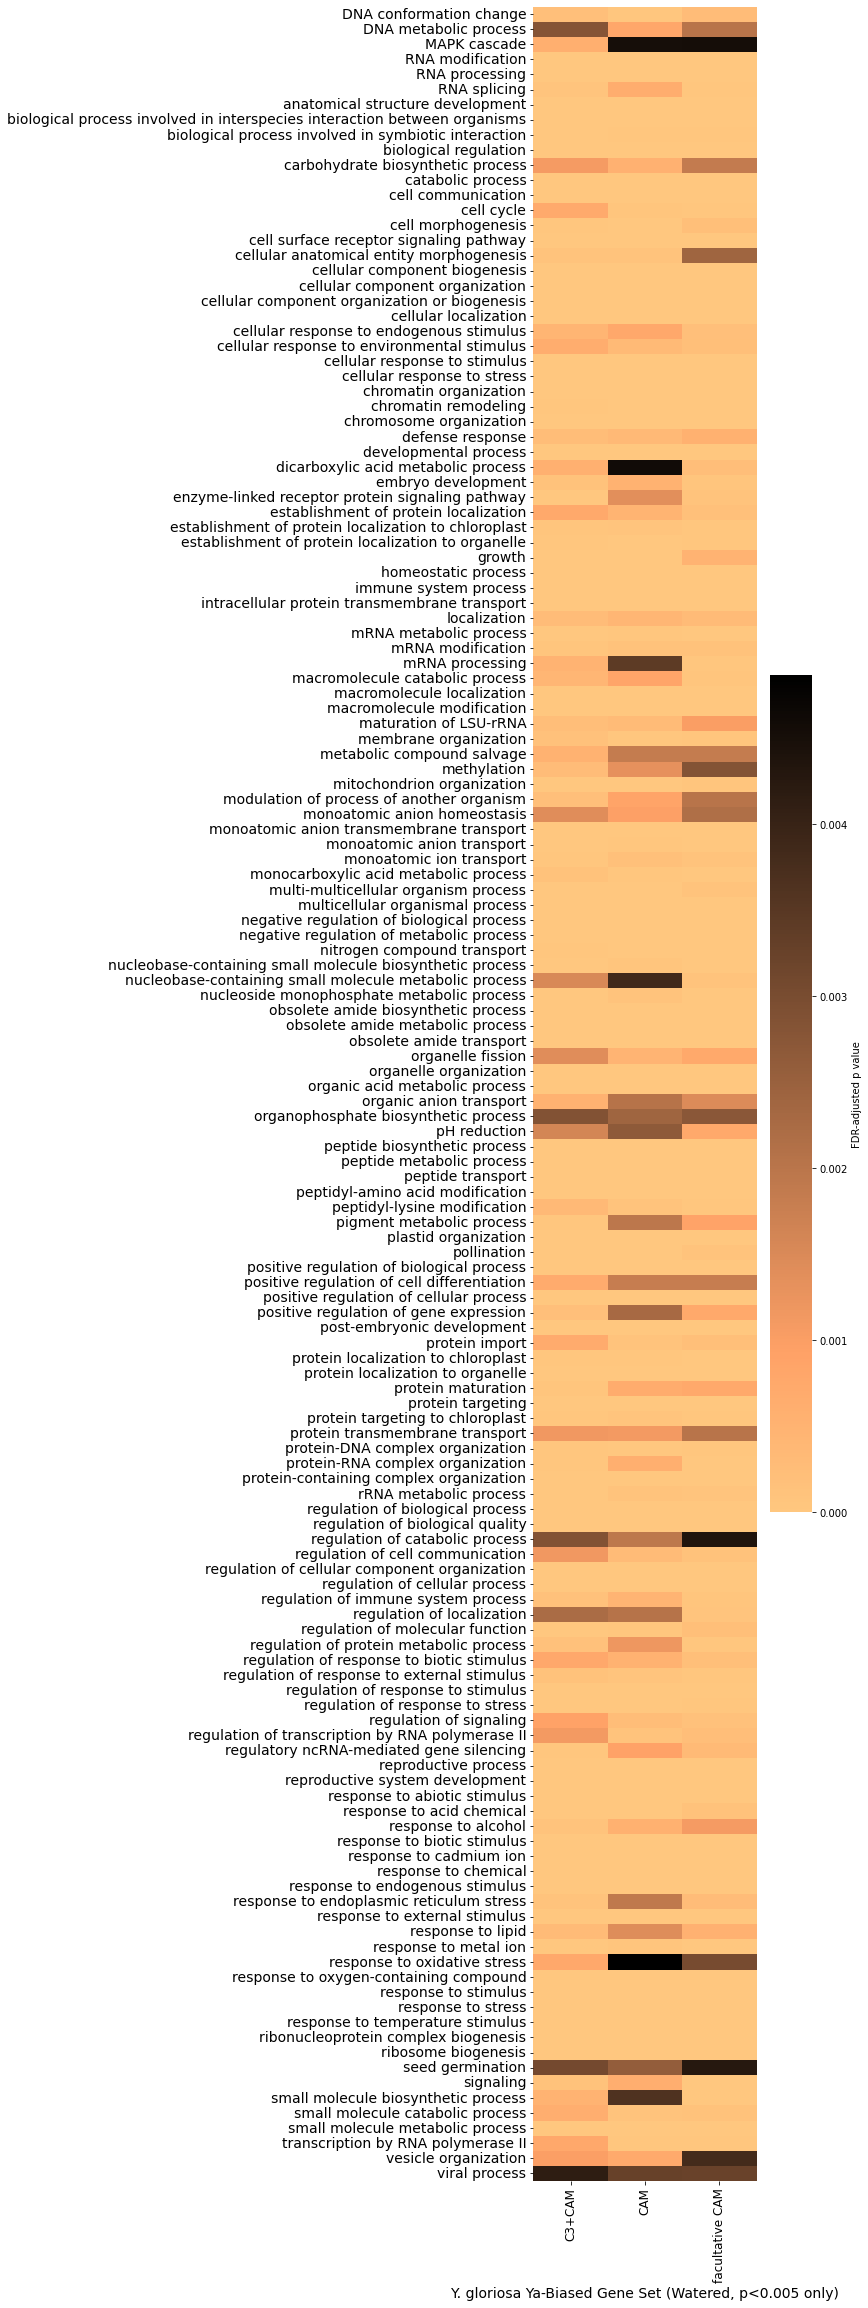

In [46]:
plt.subplots(figsize=(5,40))
sns.heatmap(plotw_reduced,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,3.5,1),labels = ["C3+CAM","CAM","facultative CAM"],fontsize=12)
plt.xlabel("Y. gloriosa Ya-Biased Gene Set (Watered, p<0.005 only)",fontsize=14)

plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaW.png",dpi=300,bbox_inches="tight")
plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaW.svg",dpi=300,bbox_inches="tight")
plt.savefig("./GO_verylowP_Revigo_heatmap_ASE_YaW.pdf",dpi=300,bbox_inches="tight")

In [47]:
# make figures for HybridExpress GO terms
subhe = heres[["GO.term","p.adj","regset","Annotated","Significant","Expected","Descr"]].merge(revhe.rename(columns={
    "TermID":"GO.term"
}))
subhe.head()

,GO.term,p.adj,regset,Annotated,Significant,Expected,Descr,Name
0,GO:0009060,4.232708e-03,C3+CAM_D_ADD,88,51,29.36,aerobic respiration,aerobic respiration
1,GO:0009060,5.705258e-04,facultative CAM_D_ADD,88,42,19.82,aerobic respiration,aerobic respiration
2,GO:0010112,1.852011e-03,C3+CAM_D_ADD,32,25,10.68,regulation of systemic acquired resistance,regulation of systemic acquired resistance
3,GO:0002181,1.216616e-03,C3+CAM_D_DOWN,89,50,29.16,cytoplasmic translation,cytoplasmic translation
4,GO:0002181,1.158513e-08,facultative CAM_D_DOWN,89,46,17.77,cytoplasmic translation,cytoplasmic translation


In [48]:
plothe = subhe.pivot(index="Descr",columns="regset",values="p.adj")
len(plothe.index)

141

In [50]:
plothe.columns

Index(['C3+CAM_D_ADD', 'C3+CAM_D_DOWN', 'C3+CAM_D_UP', 'C3+CAM_W_DOWN',
       'C3+CAM_W_ELD_P2', 'C3+CAM_W_UP', 'CAM_D_DOWN', 'CAM_D_UP',
       'CAM_W_DOWN', 'CAM_W_UP', 'facultative CAM_D_ADD',
       'facultative CAM_D_DOWN', 'facultative CAM_D_UP',
       'facultative CAM_W_DOWN', 'facultative CAM_W_UP'],
      dtype='object', name='regset')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5]),
 [Text(0.5, 0, 'C3+CAM_D_ADD'),
  Text(1.5, 0, 'C3+CAM_D_DOWN'),
  Text(2.5, 0, 'C3+CAM_D_UP'),
  Text(3.5, 0, 'C3+CAM_W_DOWN'),
  Text(4.5, 0, 'C3+CAM_W_ELD_P2'),
  Text(5.5, 0, 'C3+CAM_W_UP'),
  Text(6.5, 0, 'CAM_D_DOWN'),
  Text(7.5, 0, 'CAM_D_UP'),
  Text(8.5, 0, 'CAM_W_DOWN'),
  Text(9.5, 0, 'CAM_W_UP'),
  Text(10.5, 0, 'facultative CAM_D_ADD'),
  Text(11.5, 0, 'facultative CAM_D_DOWN'),
  Text(12.5, 0, 'facultative CAM_D_UP'),
  Text(13.5, 0, 'facultative CAM_W_DOWN'),
  Text(14.5, 0, 'facultative CAM_W_UP')])

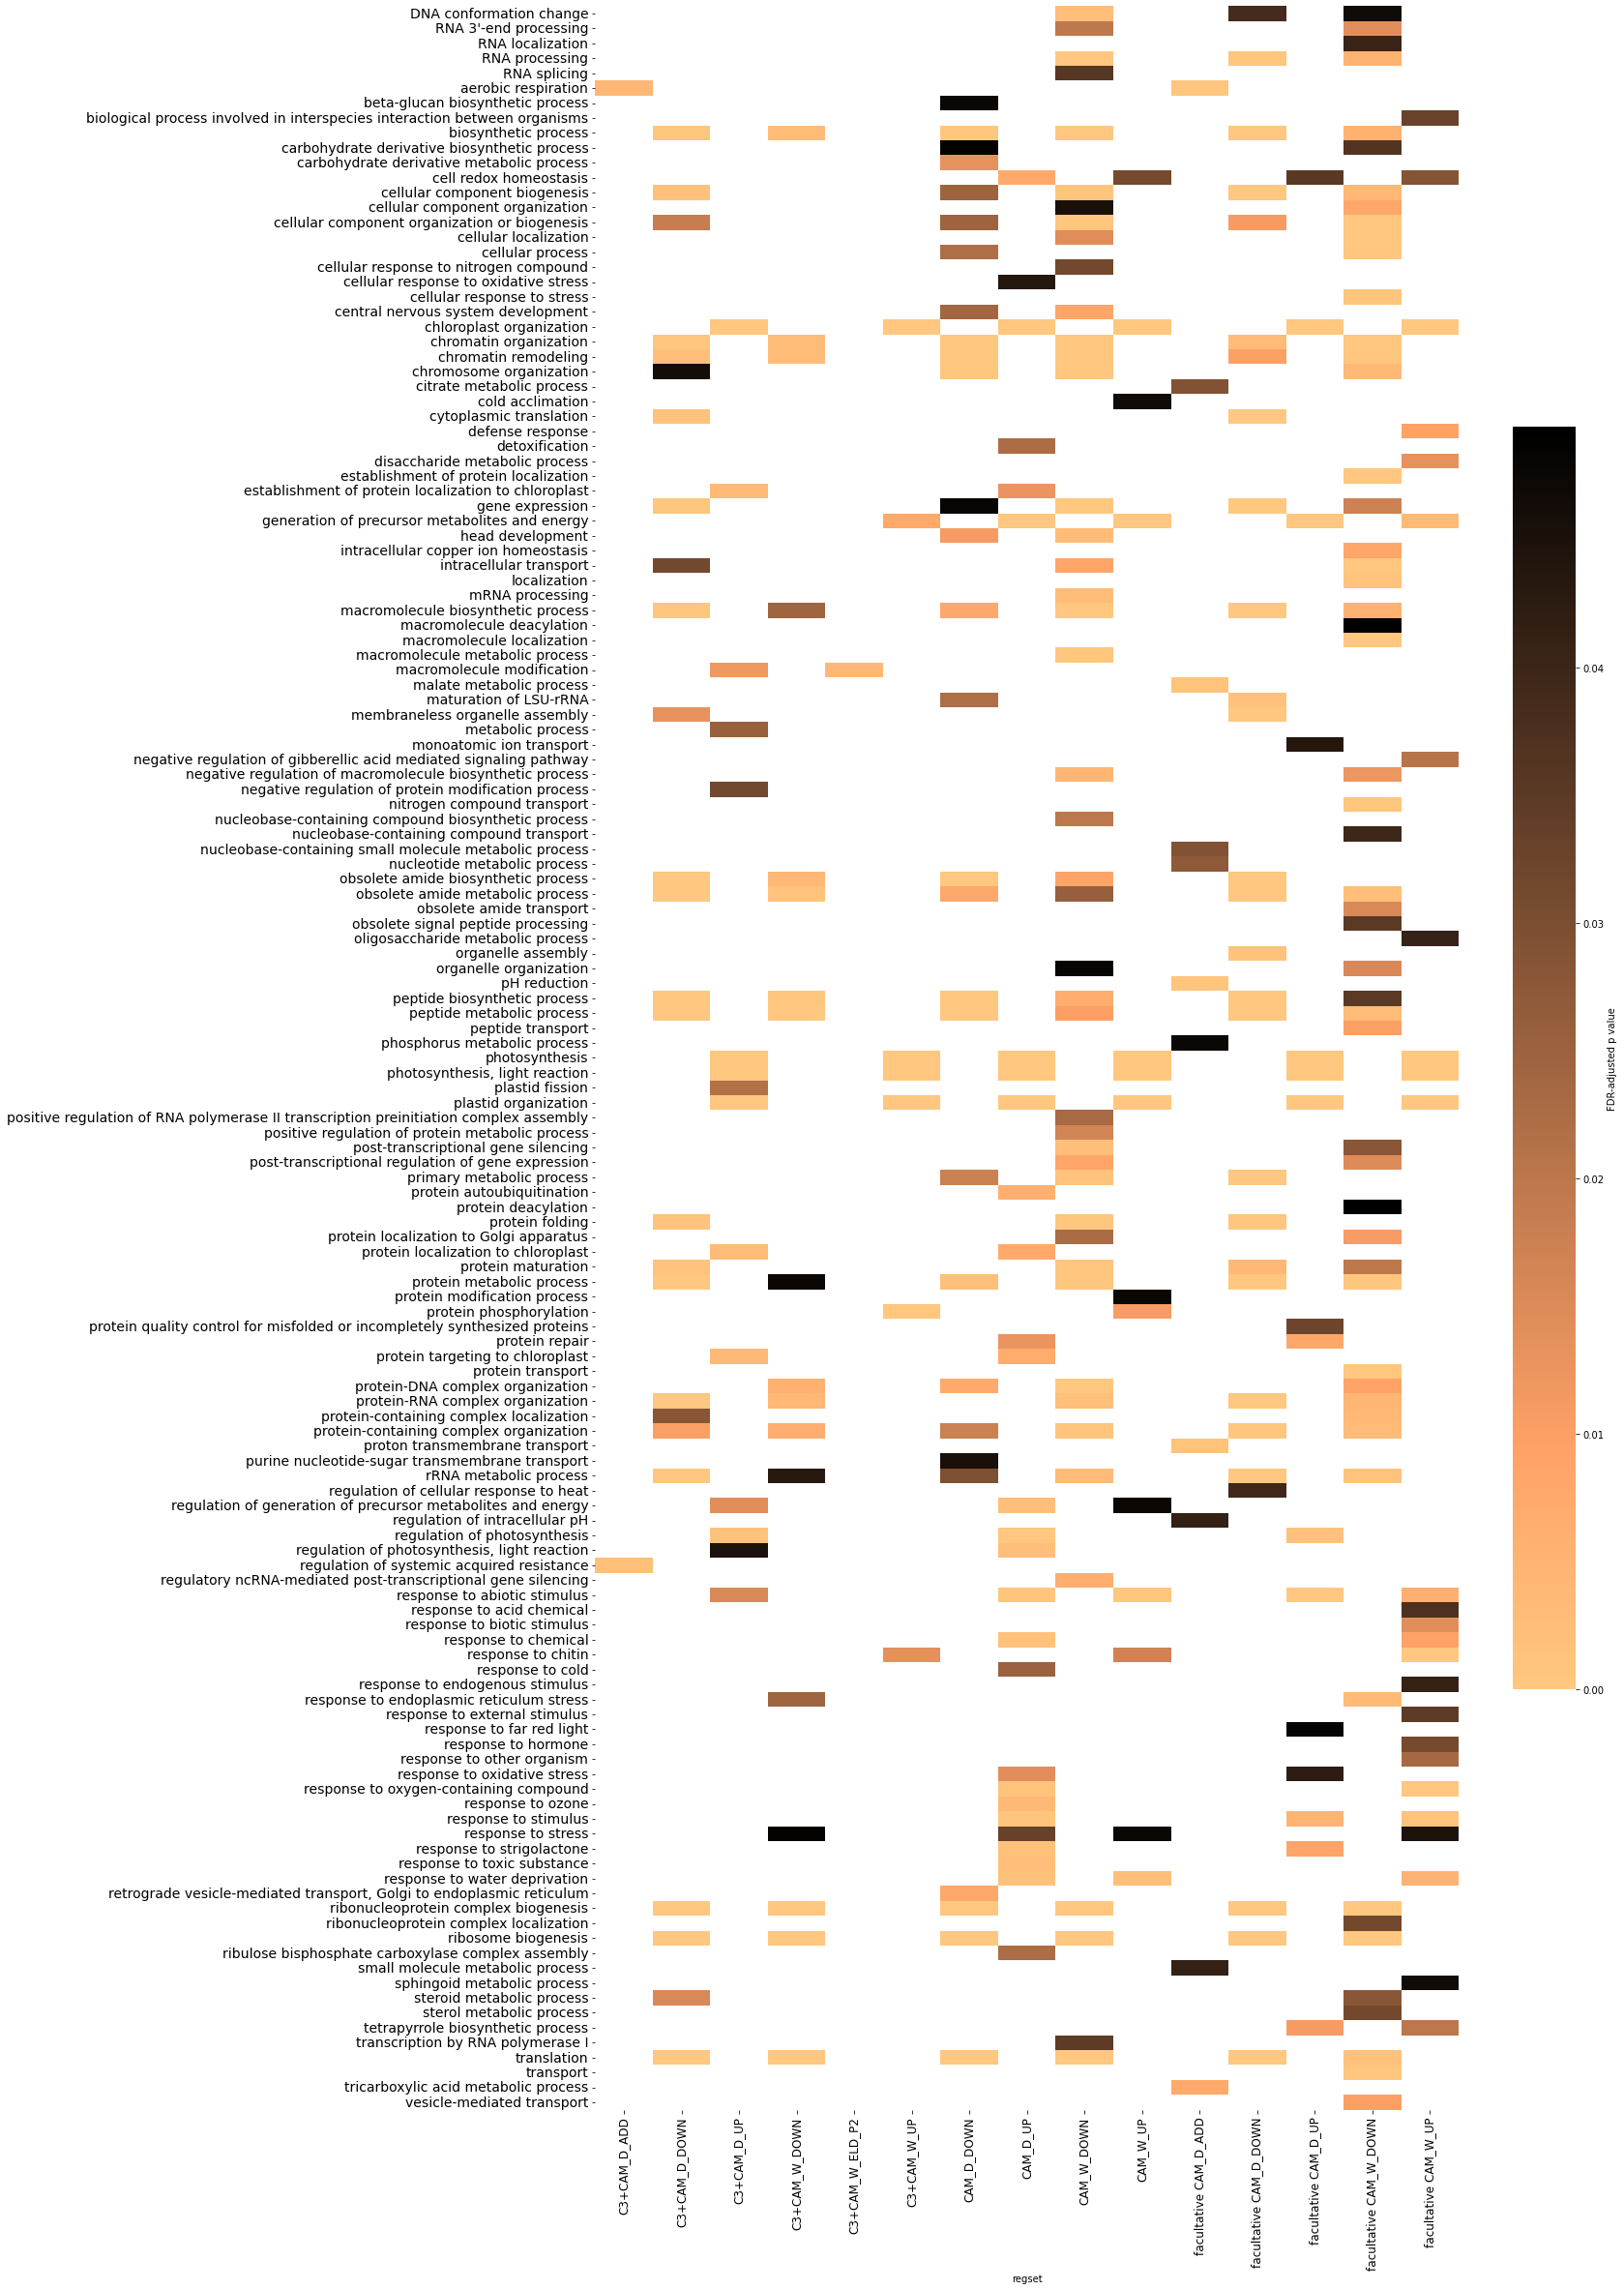

In [52]:
# try plotting everything & see how overwhelming it is
plt.subplots(figsize=(20,40))
sns.heatmap(plothe,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(fontsize=12)
#plt.xlabel("Y. gloriosa Ya-Biased Gene Set (Watered, p<0.005 only)",fontsize=14)

In [58]:
40/141

0.28368794326241137

In [62]:
# yeah, that's really not a practical plot. instead, make a plot for each class. Make a function to do this
def plot_go_class(c,d="./",pdf=plothe):
    plot = pdf[[i for i in pdf.columns if c in i]].dropna(how="all")
    xgo = len(plot.index)
    #print(xgo)
    
    plt.subplots(figsize=(10,0.3*xgo))
    sns.heatmap(plot,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
    plt.yticks(fontsize=14)
    plt.ylabel("")
    plt.xticks(fontsize=12)
    
    plt.savefig(os.path.join(d,c+"_GO_Revigo_heatmap.png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,c+"_GO_Revigo_heatmap.pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,c+"_GO_Revigo_heatmap.svg"),dpi=300,bbox_inches="tight")

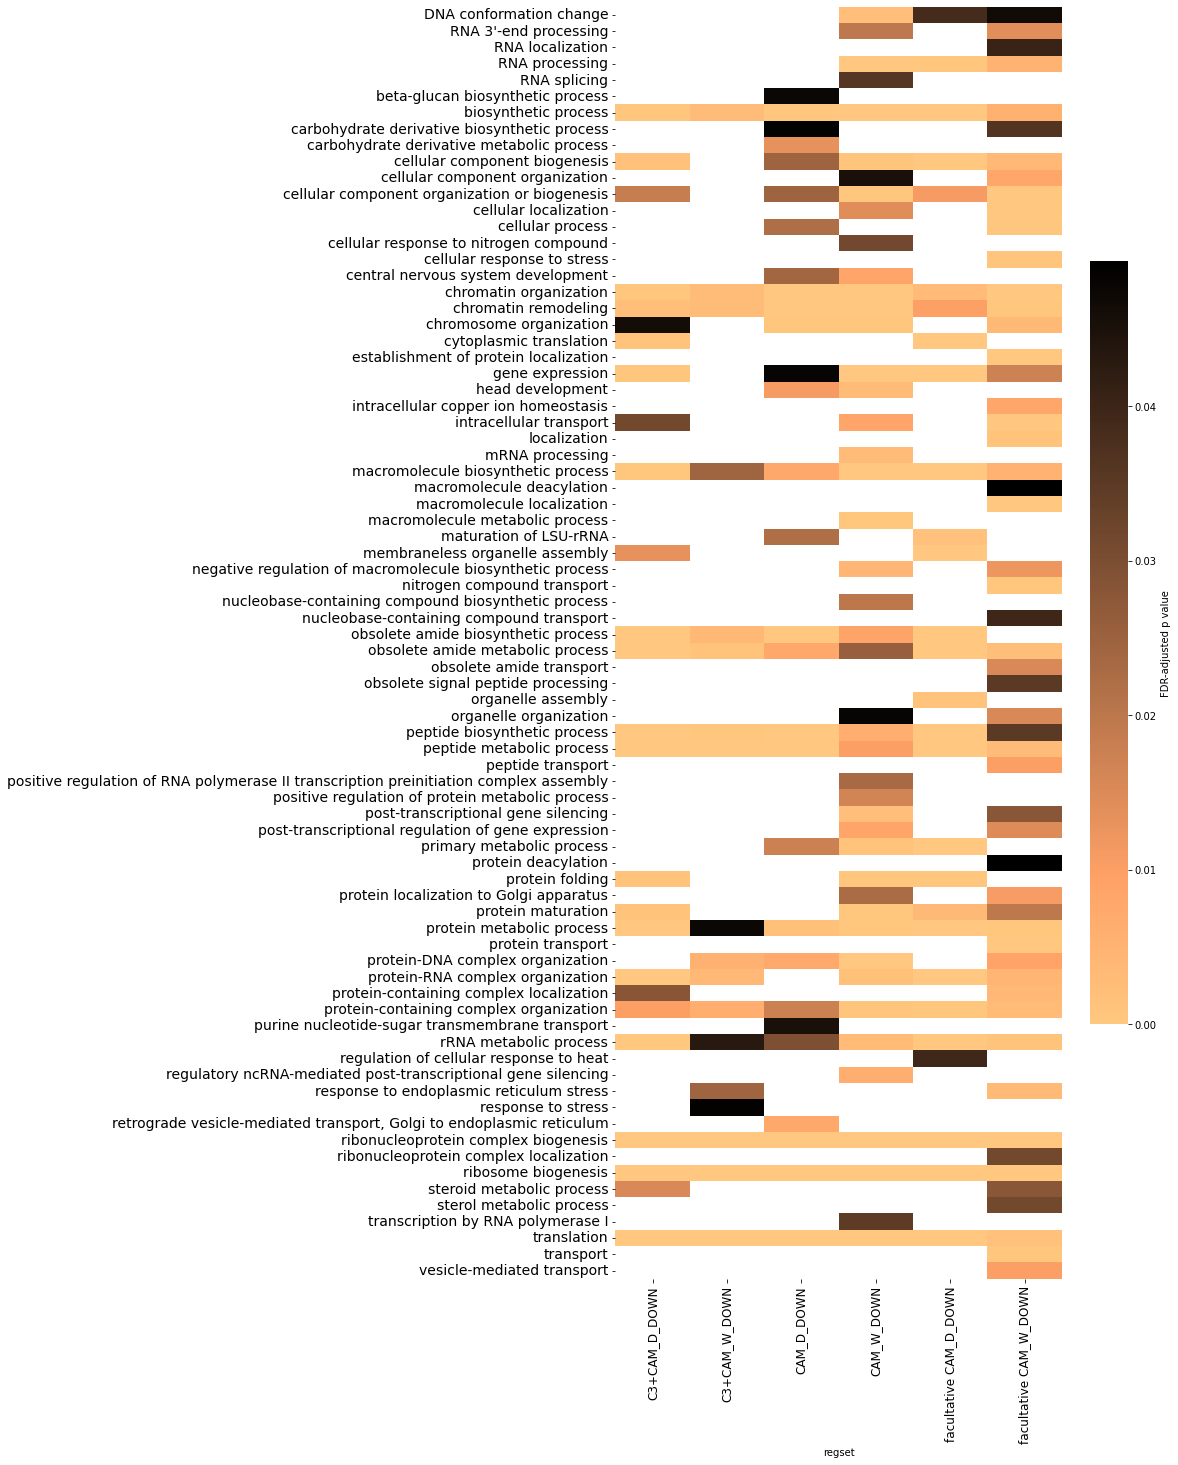

In [63]:
plot_go_class("DOWN")

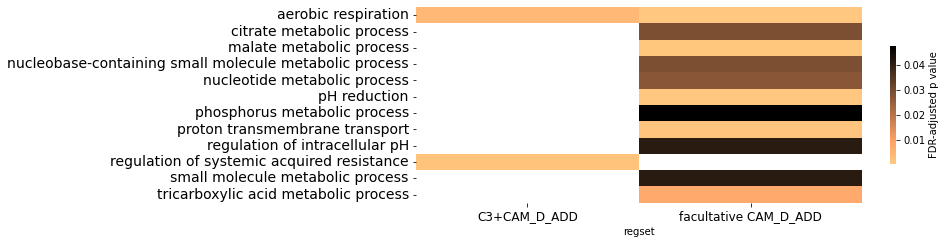

In [64]:
plot_go_class("ADD")

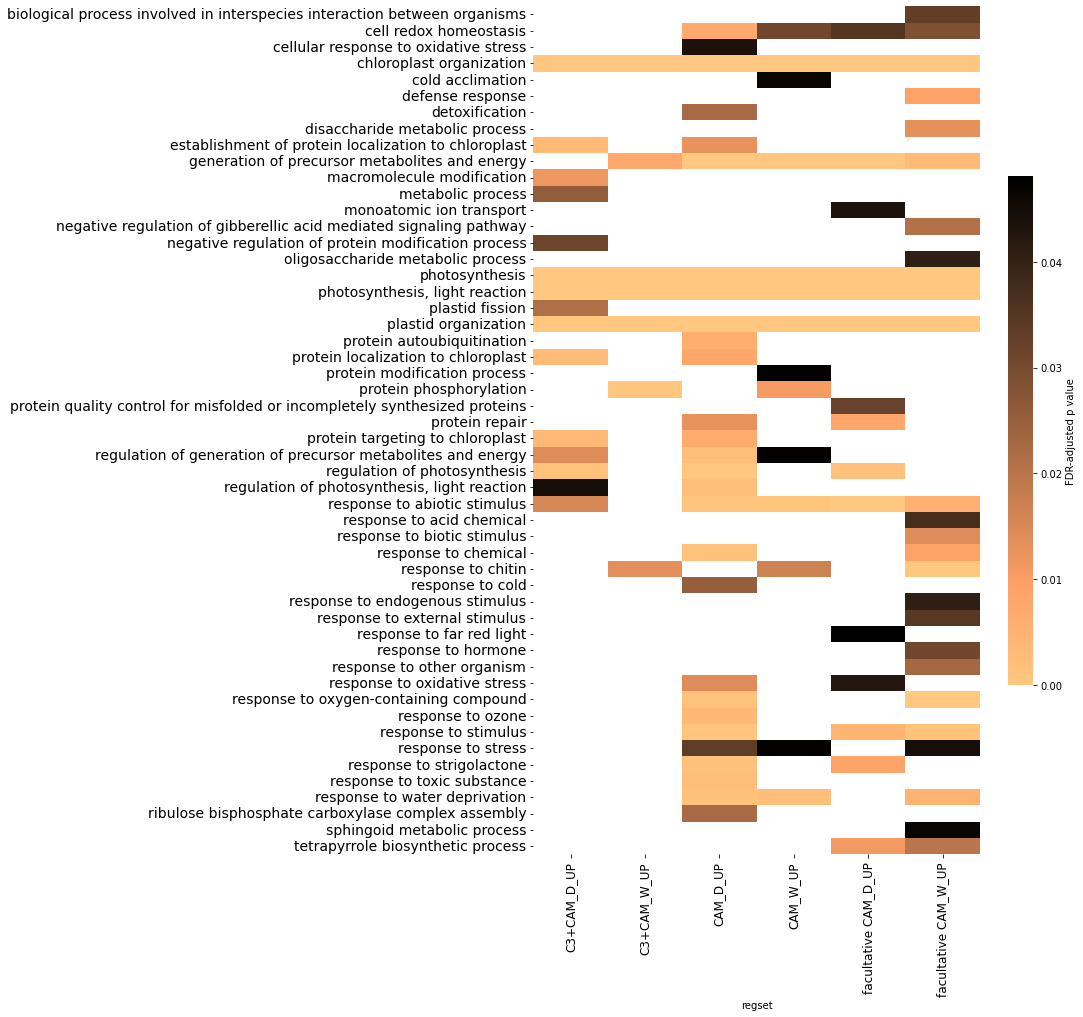

In [65]:
plot_go_class("UP")

ValueError: zero-size array to reduction operation fmin which has no identity

/home/leviathan22/.local/lib/python3.8/site-packages/matplotlib/_tight_bbox.py:67: RuntimeWarning: divide by zero encountered in double_scalars
  fig.patch.set_bounds(x0 / w1, y0 / h1,
/home/leviathan22/.local/lib/python3.8/site-packages/matplotlib/_tight_bbox.py:68: RuntimeWarning: divide by zero encountered in double_scalars
  fig.bbox.width / w1, fig.bbox.height / h1)
/home/leviathan22/.local/lib/python3.8/site-packages/matplotlib/patches.py:737: RuntimeWarning: invalid value encountered in double_scalars
  y1 = self.convert_yunits(self._y0 + self._height)
/home/leviathan22/.local/lib/python3.8/site-packages/matplotlib/transforms.py:2047: RuntimeWarning: invalid value encountered in double_scalars
  self._mtx[1, 2] += ty


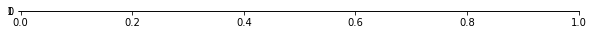

In [66]:
plot_go_class("ELD_P1")

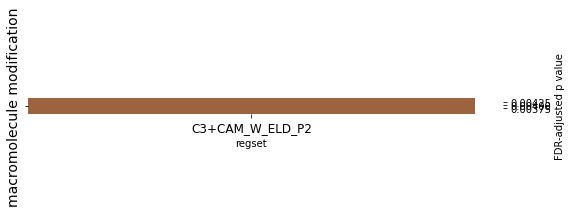

In [67]:
plot_go_class("ELD_P2")